# CS316 Project: Predicting and Optimizing Electric Vehicle Charging Stations

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import zscore
from xgboost import XGBRegressor

## Load Data

In [2]:
data = pd.read_csv('/content/charging_pile_demand_forecasting.csv')

# 1. Exploratory Data Analysis (EDA) Tasks

## 1.1 - Data Quality & Structure (Data Cleaning and Feature Engineering)

In [3]:
print("First 5 rows:")
data.head()

First 5 rows:


,charging_station_id,timestamp,charging_duration,energy_consumed,no_of_evs_charging,traffic_flow,peak_traffic_hours,vehicle_type,avg_vehicle_speed,temperature,...,wind_speed,location_latitude,location_longitude,distance_to_nearest_road,charging_station_density,population_density,public_holiday_or_event,charging_price_per_kWh,government_incentives,charging_pile_usage_rate
0,1,2023-01-05 10:00:00,0.995879,17.443426,1,247,8,truck,33.173233,20.532106,...,10.871362,35.961448,121.051683,2.544341,1,3057,0,0.276276,0,1.470604
1,3,2023-01-13 22:00:00,0.617119,3.663894,2,497,8,sedan,54.092240,9.525288,...,11.427530,36.391309,120.357219,4.976256,1,3942,1,0.265587,1,1.430960
2,4,2023-01-17 15:00:00,0.795066,8.649020,4,301,18,sedan,46.175604,14.964203,...,13.463662,35.141676,120.387317,4.339104,5,3522,0,0.314434,1,1.987030
3,4,2023-01-01 18:00:00,2.032966,39.194571,3,350,12,sedan,36.174312,34.757135,...,6.965325,36.293430,120.639229,3.416016,4,4661,0,0.405844,1,3.041443
4,1,2023-01-23 05:00:00,1.901431,13.505719,3,146,8,sedan,39.370476,-9.812843,...,10.694804,35.734327,120.735113,2.742282,4,2592,1,0.277614,0,2.936007


In [4]:
print("Data info:")
data.info()

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   charging_station_id       1000 non-null   int64  
 1   timestamp                 1000 non-null   object 
 2   charging_duration         1000 non-null   float64
 3   energy_consumed           1000 non-null   float64
 4   no_of_evs_charging        1000 non-null   int64  
 5   traffic_flow              1000 non-null   int64  
 6   peak_traffic_hours        1000 non-null   int64  
 7   vehicle_type              1000 non-null   object 
 8   avg_vehicle_speed         1000 non-null   float64
 9   temperature               1000 non-null   float64
 10  humidity                  1000 non-null   float64
 11  precipitation             1000 non-null   float64
 12  wind_speed                1000 non-null   float64
 13  location_latitude         1000 non-null   float64
 14

In [5]:
data.describe()

,charging_station_id,charging_duration,energy_consumed,no_of_evs_charging,traffic_flow,peak_traffic_hours,avg_vehicle_speed,temperature,humidity,precipitation,wind_speed,location_latitude,location_longitude,distance_to_nearest_road,charging_station_density,population_density,public_holiday_or_event,charging_price_per_kWh,government_incentives,charging_pile_usage_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.488000,1.491255,19.070728,2.918000,304.810000,14.440000,49.783677,12.114343,60.658853,5.103054,7.556539,36.000915,120.999177,2.756547,5.457000,2990.857000,0.464000,0.299471,0.494000,2.455258
std,1.122995,0.582451,10.365440,1.430147,117.137804,4.742667,16.889935,13.084949,17.365383,2.831283,4.327104,0.595517,0.572148,1.267449,2.880703,1150.634403,0.498952,0.114027,0.500214,0.657190
min,1.000000,0.500106,2.945044,1.000000,100.000000,8.000000,20.134617,-9.999566,30.010477,0.001920,0.000692,35.000105,120.000058,0.502724,1.000000,1002.000000,0.000000,0.100446,0.000000,0.932454
25%,1.000000,0.989487,10.661380,2.000000,203.000000,12.000000,34.899206,0.665003,45.840241,2.779946,3.758380,35.503171,120.491473,1.704556,3.000000,1964.500000,0.000000,0.203086,0.000000,1.933508
50%,2.000000,1.459878,17.122555,3.000000,303.000000,12.000000,49.718721,11.566503,60.785860,5.163482,7.558012,36.011401,120.999087,2.730309,5.000000,2962.500000,0.000000,0.294241,0.000000,2.472486
75%,3.250000,2.003686,25.486647,4.000000,411.250000,18.000000,63.365790,23.460903,75.614138,7.504183,11.284043,36.544317,121.493472,3.812675,8.000000,3961.500000,1.000000,0.397966,1.000000,2.977910
max,4.000000,2.498933,48.873669,5.000000,500.000000,20.000000,79.912703,34.961123,89.993896,9.995467,14.977760,36.999647,121.998013,4.991859,10.000000,5000.000000,1.000000,0.499526,1.000000,3.919199


### 1.1.1 - Check/Handle missing values in each column

In [6]:
# i. Check/handle missing values in each column
print("Missing values per column:")
data.isnull().sum()

Missing values per column:


,0
charging_station_id,0
timestamp,0
charging_duration,0
energy_consumed,0
no_of_evs_charging,0
traffic_flow,0
peak_traffic_hours,0
vehicle_type,0
avg_vehicle_speed,0
temperature,0


In [7]:
print("Percentage of missing values per column:")
missing_val = data.isnull().sum() / len(data)
print(missing_val)

Percentage of missing values per column:
charging_station_id         0.0
timestamp                   0.0
charging_duration           0.0
energy_consumed             0.0
no_of_evs_charging          0.0
traffic_flow                0.0
peak_traffic_hours          0.0
vehicle_type                0.0
avg_vehicle_speed           0.0
temperature                 0.0
humidity                    0.0
precipitation               0.0
wind_speed                  0.0
location_latitude           0.0
location_longitude          0.0
distance_to_nearest_road    0.0
charging_station_density    0.0
population_density          0.0
public_holiday_or_event     0.0
charging_price_per_kWh      0.0
government_incentives       0.0
charging_pile_usage_rate    0.0
dtype: float64


Due to no missing values found in the dataset, no need for handling msising values.

### 1.1.2 - Idenitfy data types (categorical, numerical, text)

In [8]:
data['timestamp'] = pd.to_datetime(data['timestamp'])


# ii. Identify column types
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()


print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)



Numeric columns: ['charging_station_id', 'charging_duration', 'energy_consumed', 'no_of_evs_charging', 'traffic_flow', 'peak_traffic_hours', 'avg_vehicle_speed', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'location_latitude', 'location_longitude', 'distance_to_nearest_road', 'charging_station_density', 'population_density', 'public_holiday_or_event', 'charging_price_per_kWh', 'government_incentives', 'charging_pile_usage_rate']
Categorical columns: ['timestamp', 'vehicle_type']


### 1.1.3 - Convert non-numeric columns into machine-readable formats via one-hot encoding

In [9]:
data = pd.get_dummies(data, columns=['vehicle_type'], drop_first=True)

### 1.1.4 - Clean/Standardize features

In [10]:
data['timestamp'] = pd.to_datetime(data['timestamp'])

data['hour'] = data['timestamp'].dt.hour
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['month'] = data['timestamp'].dt.month
data['year'] = data['timestamp'].dt.year # 1.1.5 - Extract Year from "Released_Year"

In [11]:
data = data.drop(columns=['timestamp','vehicle_type_sedan','vehicle_type_truck','month','year'], errors='ignore')

In [12]:
data.dtypes

,0
charging_station_id,int64
charging_duration,float64
energy_consumed,float64
no_of_evs_charging,int64
traffic_flow,int64
peak_traffic_hours,int64
avg_vehicle_speed,float64
temperature,float64
humidity,float64
precipitation,float64


In [13]:
target_col = 'charging_pile_usage_rate'
feature_cols = [c for c in data.columns if c != target_col]

X = data[feature_cols]
y = data[target_col]

In [14]:
data['day_of_week_unscaled'] = data['day_of_week']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


print("\nNumber of features:", len(feature_cols))
print("Features:", feature_cols)
print("Target:", target_col)


Number of features: 21
Features: ['charging_station_id', 'charging_duration', 'energy_consumed', 'no_of_evs_charging', 'traffic_flow', 'peak_traffic_hours', 'avg_vehicle_speed', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'location_latitude', 'location_longitude', 'distance_to_nearest_road', 'charging_station_density', 'population_density', 'public_holiday_or_event', 'charging_price_per_kWh', 'government_incentives', 'hour', 'day_of_week']
Target: charging_pile_usage_rate


### 1.1.6 - Convert "time" to numeric

Dataset does not include data similar to this; time columns are already numeric

### 1.1.7 - Feature Engineering

In [15]:
# new features (day/month/year was created above)

# Duration per EV (important real-world indicator)
df = data.copy()
df['duration_per_ev'] = df['charging_duration'] / (df['no_of_evs_charging'])

# Energy per minute (efficiency/usage indicator)
df['energy_per_min'] = df['energy_consumed'] / (df['charging_duration'])

#rolling
df['usage_rate_roll3'] = df['charging_pile_usage_rate'].rolling(window=3).mean().bfill()

In [16]:
df.columns

Index(['charging_station_id', 'charging_duration', 'energy_consumed',
       'no_of_evs_charging', 'traffic_flow', 'peak_traffic_hours',
       'avg_vehicle_speed', 'temperature', 'humidity', 'precipitation',
       'wind_speed', 'location_latitude', 'location_longitude',
       'distance_to_nearest_road', 'charging_station_density',
       'population_density', 'public_holiday_or_event',
       'charging_price_per_kWh', 'government_incentives',
       'charging_pile_usage_rate', 'hour', 'day_of_week',
       'day_of_week_unscaled', 'duration_per_ev', 'energy_per_min',
       'usage_rate_roll3'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   charging_station_id       1000 non-null   int64  
 1   charging_duration         1000 non-null   float64
 2   energy_consumed           1000 non-null   float64
 3   no_of_evs_charging        1000 non-null   int64  
 4   traffic_flow              1000 non-null   int64  
 5   peak_traffic_hours        1000 non-null   int64  
 6   avg_vehicle_speed         1000 non-null   float64
 7   temperature               1000 non-null   float64
 8   humidity                  1000 non-null   float64
 9   precipitation             1000 non-null   float64
 10  wind_speed                1000 non-null   float64
 11  location_latitude         1000 non-null   float64
 12  location_longitude        1000 non-null   float64
 13  distance_to_nearest_road  1000 non-null   float64
 14  charging_

## 1.2. Record-Level Analysis

### 1.2.1 - Identify top records in different features

In [18]:
print("\n=== Record-Level Analysis ===")

# 1. Top 5 highest usage rates
print("\nTop 5 Charging Sessions by Usage Rate:")
top_usage = df.sort_values(by='charging_pile_usage_rate', ascending=False).head()
print(top_usage)

# 2. Top 5 longest charging durations
print("\nTop 5 Longest Charging Durations:")
top_duration = df.sort_values(by='charging_duration', ascending=False).head()
print(top_duration)

# 3. Top 5 highest energy consumed
print("\nTop 5 Highest Energy Consumption Sessions:")
top_energy = df.sort_values(by='energy_consumed', ascending=False).head()
print(top_energy)

# 3. Top 5 highest energy consumed
print("\nTop 5 Highest Energy Consumption Sessions:")
top_energy = df.sort_values(by='energy_consumed', ascending=False).head()
print(top_energy)


# 4. Top 5 busiest charging stations (highest number of EVs)
print("\nTop 5 Sessions with Most EVs Charging:")
top_evs = df.sort_values(by='no_of_evs_charging', ascending=False).head()
print(top_evs)

# 5. Top 5 highest traffic conditions
print("\nTop 5 Sessions with Highest Traffic Flow:")
top_traffic = df.sort_values(by='traffic_flow', ascending=False).head()
print(top_traffic)


# 6 — Top 5 highest duration_per_ev (engineered)
print("\nTop 5 Duration per ev:")
top_duration = df.sort_values(by='duration_per_ev', ascending=False).head()
print(top_duration)

# 7 — Top 5 highest energy_per_min (engineered)
print("\nTop 5 Highest energy per min:")
top_energy = df.sort_values(by='energy_per_min', ascending=False).head()
print(top_energy)

# 8 — Top 5 highest usage_rate_roll3 (engineered)
print("\nTop 5 igh usage rate roll3:")
top_roll = df.sort_values(by='usage_rate_roll3', ascending=False).head()
print(top_roll)


=== Record-Level Analysis ===

Top 5 Charging Sessions by Usage Rate:
     charging_station_id  charging_duration  energy_consumed  \
662                    3           2.423584        15.966361   
171                    3           2.494680        43.494452   
608                    3           2.480800        17.484586   
800                    3           2.458104        21.052889   
213                    3           2.352465        32.651217   

     no_of_evs_charging  traffic_flow  peak_traffic_hours  avg_vehicle_speed  \
662                   5           287                  18          31.305158   
171                   5           187                  20          33.665091   
608                   5           107                   8          48.855321   
800                   5           246                  12          46.137256   
213                   5           447                  18          50.707810   

     temperature   humidity  precipitation  ...  public_holiday

### 1.2.2 - Analyze Distribution

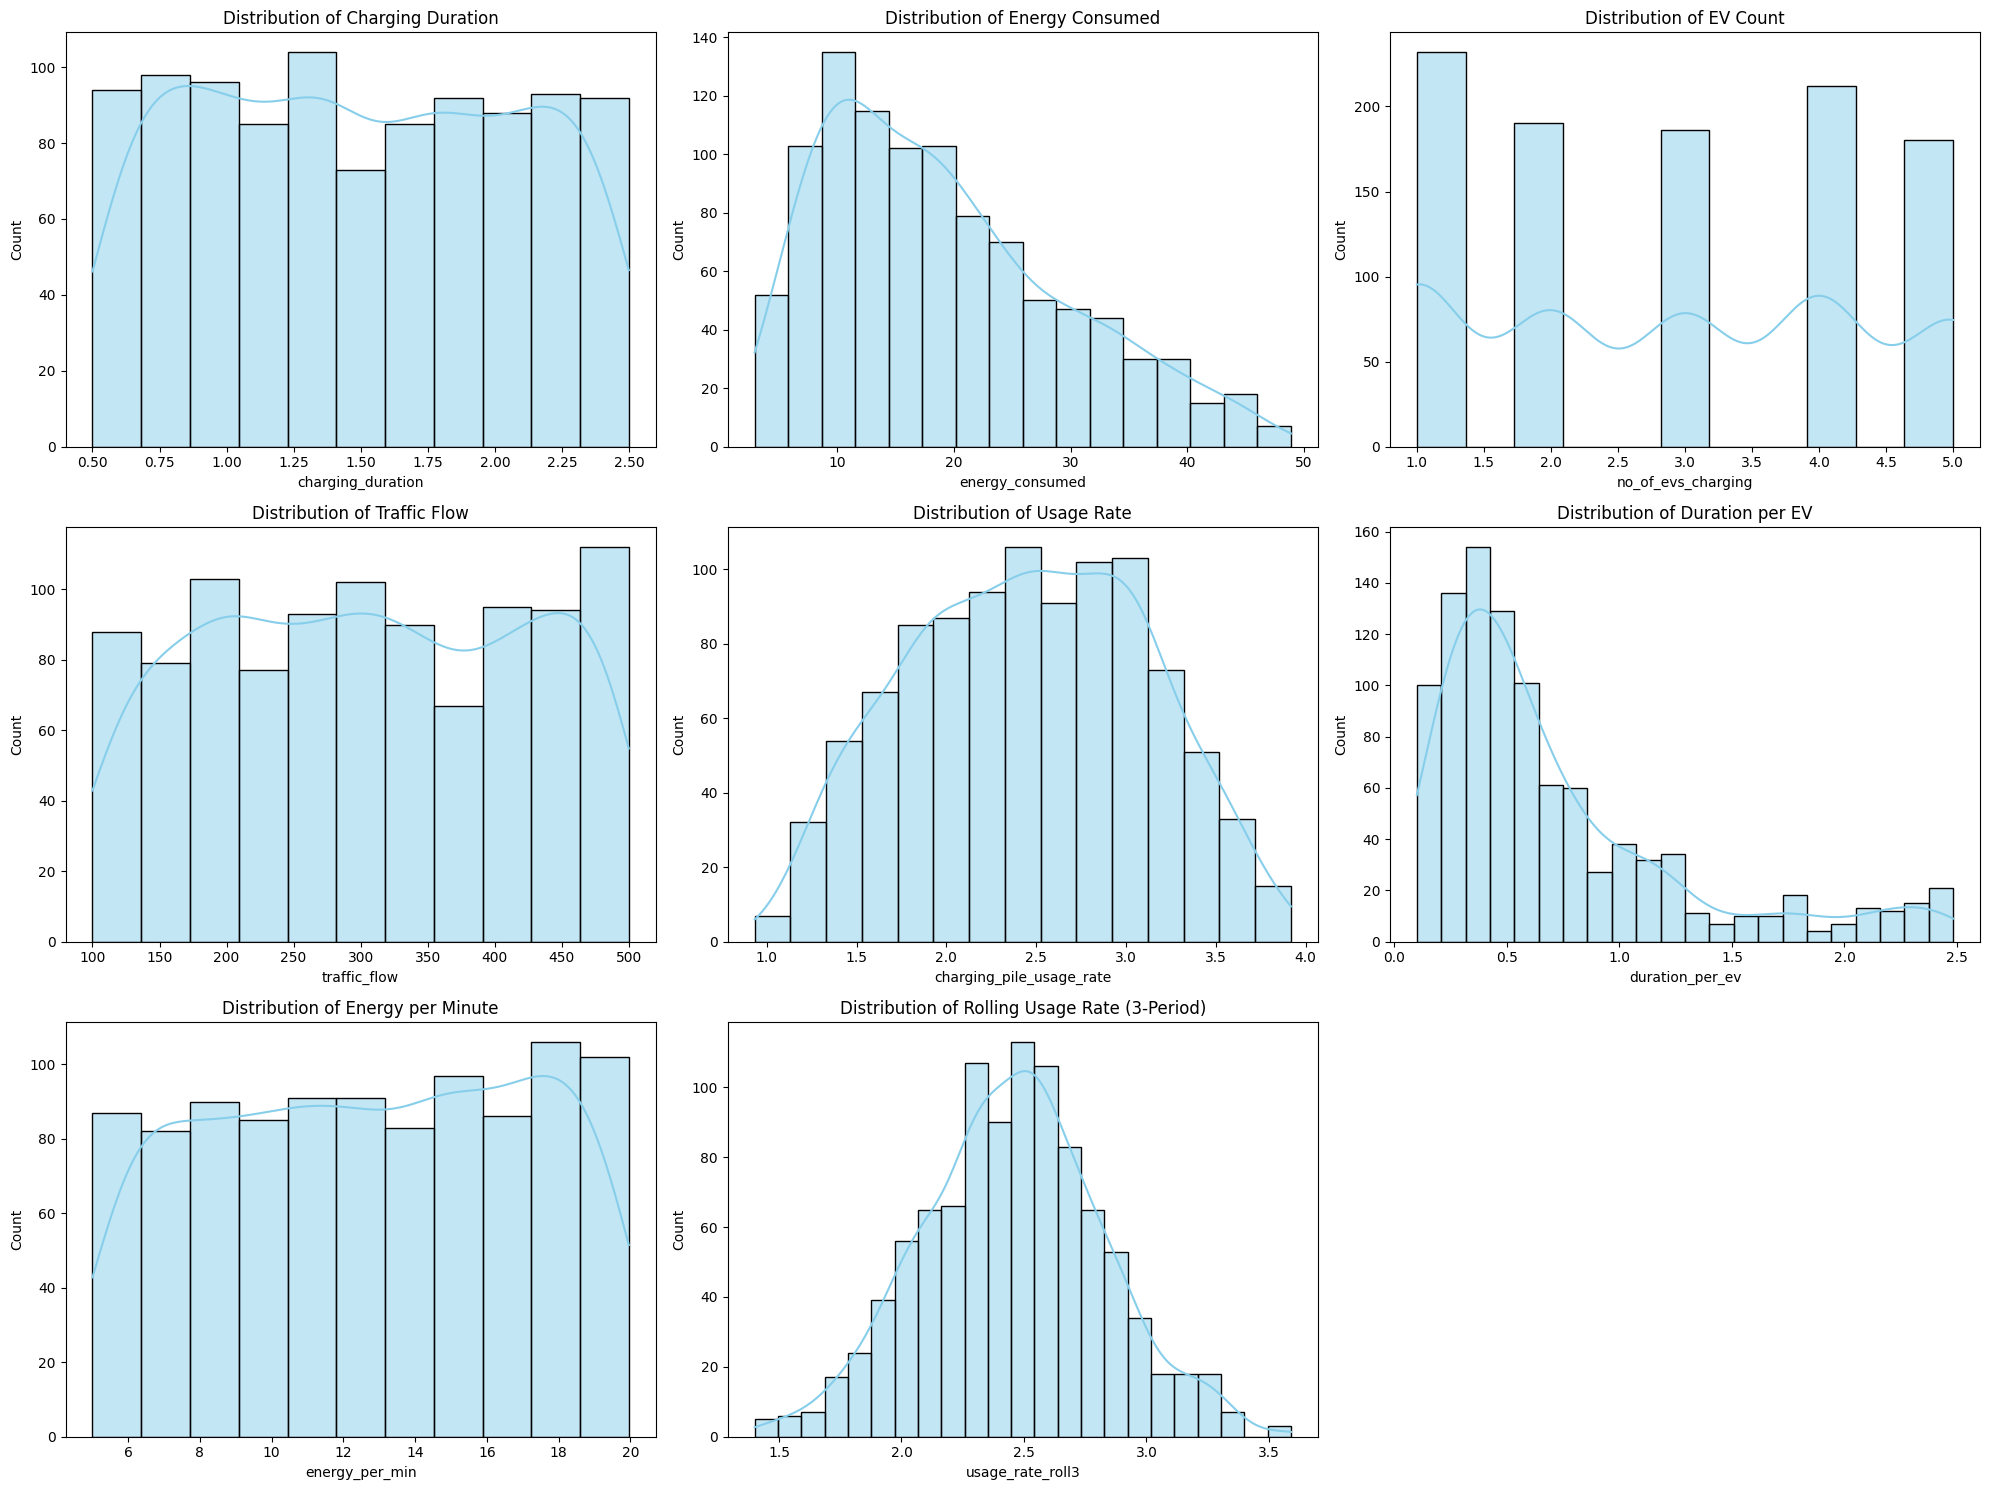

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

# 1 — Charging Duration (Histogram + KDE)
sns.histplot(df['charging_duration'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution of Charging Duration")

# 2 — Energy Consumed
sns.histplot(df['energy_consumed'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title("Distribution of Energy Consumed")

# 3 — Number of EVs Charging
sns.histplot(df['no_of_evs_charging'], kde=True, ax=axes[2], color='skyblue')
axes[2].set_title("Distribution of EV Count")

# 4 — Traffic Flow
sns.histplot(df['traffic_flow'], kde=True, ax=axes[3], color='skyblue')
axes[3].set_title("Distribution of Traffic Flow")

# 5 — Charging Pile Usage Rate (Target)
sns.histplot(df['charging_pile_usage_rate'], kde=True, ax=axes[4], color='skyblue')
axes[4].set_title("Distribution of Usage Rate")

# ENGINEERED FEATURES:
# 6 — Duration per EV
sns.histplot(df['duration_per_ev'], kde=True, ax=axes[5], color='skyblue')
axes[5].set_title("Distribution of Duration per EV")

# 7 — Energy per Minute
sns.histplot(df['energy_per_min'], kde=True, ax=axes[6], color='skyblue')
axes[6].set_title("Distribution of Energy per Minute")

# 8 — Rolling Usage Rate (3)
sns.histplot(df['usage_rate_roll3'], kde=True, ax=axes[7], color='skyblue')
axes[7].set_title("Distribution of Rolling Usage Rate (3-Period)")

# Empty subplot
axes[8].axis("off")

plt.tight_layout()
plt.show()

### 1.2.3 - Identify Outliers

In [20]:
features_to_check = [ "charging_duration", "energy_consumed","no_of_evs_charging", "traffic_flow", "charging_pile_usage_rate", "duration_per_ev", "energy_per_min", "usage_rate_roll3"]

print("\n=== Outliers Using Z-Score (>3 SD) ===")

z_scores = df[features_to_check].apply(zscore)
z_outliers = (np.abs(z_scores) > 3)

for col in features_to_check:
    count = z_outliers[col].sum()
    print(f"{col}: {count} outliers")


=== Outliers Using Z-Score (>3 SD) ===
charging_duration: 0 outliers
energy_consumed: 0 outliers
no_of_evs_charging: 0 outliers
traffic_flow: 0 outliers
charging_pile_usage_rate: 0 outliers
duration_per_ev: 13 outliers
energy_per_min: 0 outliers
usage_rate_roll3: 2 outliers


## 1.3 - Relationships between Variables

### 1.3.1 - Correlation

In [21]:
correlation_matrix = df.corr()
print("\nCorrelation Matrix:")
correlation_matrix


Correlation Matrix:


,charging_station_id,charging_duration,energy_consumed,no_of_evs_charging,traffic_flow,peak_traffic_hours,avg_vehicle_speed,temperature,humidity,precipitation,...,public_holiday_or_event,charging_price_per_kWh,government_incentives,charging_pile_usage_rate,hour,day_of_week,day_of_week_unscaled,duration_per_ev,energy_per_min,usage_rate_roll3
charging_station_id,1.000000,-0.005403,-0.022190,-0.004353,-0.027640,-0.018178,-0.036150,-0.031205,-0.051881,0.008360,...,-0.013277,-0.027085,0.067587,-0.007454,0.065421,-0.031505,-0.031505,0.012160,-0.038768,-0.062824
charging_duration,-0.005403,1.000000,0.733838,0.001511,-0.020354,-0.025597,-0.042634,-0.026366,0.032269,-0.002460,...,-0.003420,-0.044847,0.002644,0.886080,-0.015676,0.002688,0.002688,0.505986,0.034292,0.494038
energy_consumed,-0.022190,0.733838,1.000000,-0.036923,-0.066526,-0.041866,-0.047462,-0.005800,0.035901,-0.002111,...,0.013136,-0.032053,-0.013442,0.631940,-0.007291,-0.024955,-0.024955,0.396454,0.656256,0.321796
no_of_evs_charging,-0.004353,0.001511,-0.036923,1.000000,0.000690,-0.086766,0.002542,-0.029149,-0.016813,-0.004831,...,0.056179,0.017561,0.016103,0.443917,-0.018268,-0.016649,-0.016649,-0.728309,-0.066685,0.278896
traffic_flow,-0.027640,-0.020354,-0.066526,0.000690,1.000000,0.020119,0.008009,-0.041311,0.015359,-0.021917,...,0.015092,-0.020686,0.034677,0.017837,0.043125,0.018079,0.018079,-0.030163,-0.081599,0.007817
peak_traffic_hours,-0.018178,-0.025597,-0.041866,-0.086766,0.020119,1.000000,-0.015043,0.008865,-0.009255,-0.001211,...,-0.038985,-0.059584,0.010397,-0.059822,0.039971,-0.003813,-0.003813,0.044762,-0.033130,-0.038542
avg_vehicle_speed,-0.036150,-0.042634,-0.047462,0.002542,0.008009,-0.015043,1.000000,-0.017837,0.012510,-0.022521,...,0.011146,-0.001311,-0.018315,-0.013341,0.050129,-0.015396,-0.015396,-0.020894,-0.023948,-0.024050
temperature,-0.031205,-0.026366,-0.005800,-0.029149,-0.041311,0.008865,-0.017837,1.000000,-0.010709,-0.028975,...,-0.026067,-0.006804,0.013739,-0.041222,0.001238,-0.050787,-0.050787,0.013467,0.031549,-0.018800
humidity,-0.051881,0.032269,0.035901,-0.016813,0.015359,-0.009255,0.012510,-0.010709,1.000000,0.004666,...,0.069231,0.010779,0.031591,0.001704,0.003153,-0.008574,-0.008574,0.019024,0.014028,-0.018572
precipitation,0.008360,-0.002460,-0.002111,-0.004831,-0.021917,-0.001211,-0.022521,-0.028975,0.004666,1.000000,...,0.028746,0.050816,0.006985,0.080022,0.014422,0.047326,0.047326,0.017023,-0.009082,0.049002


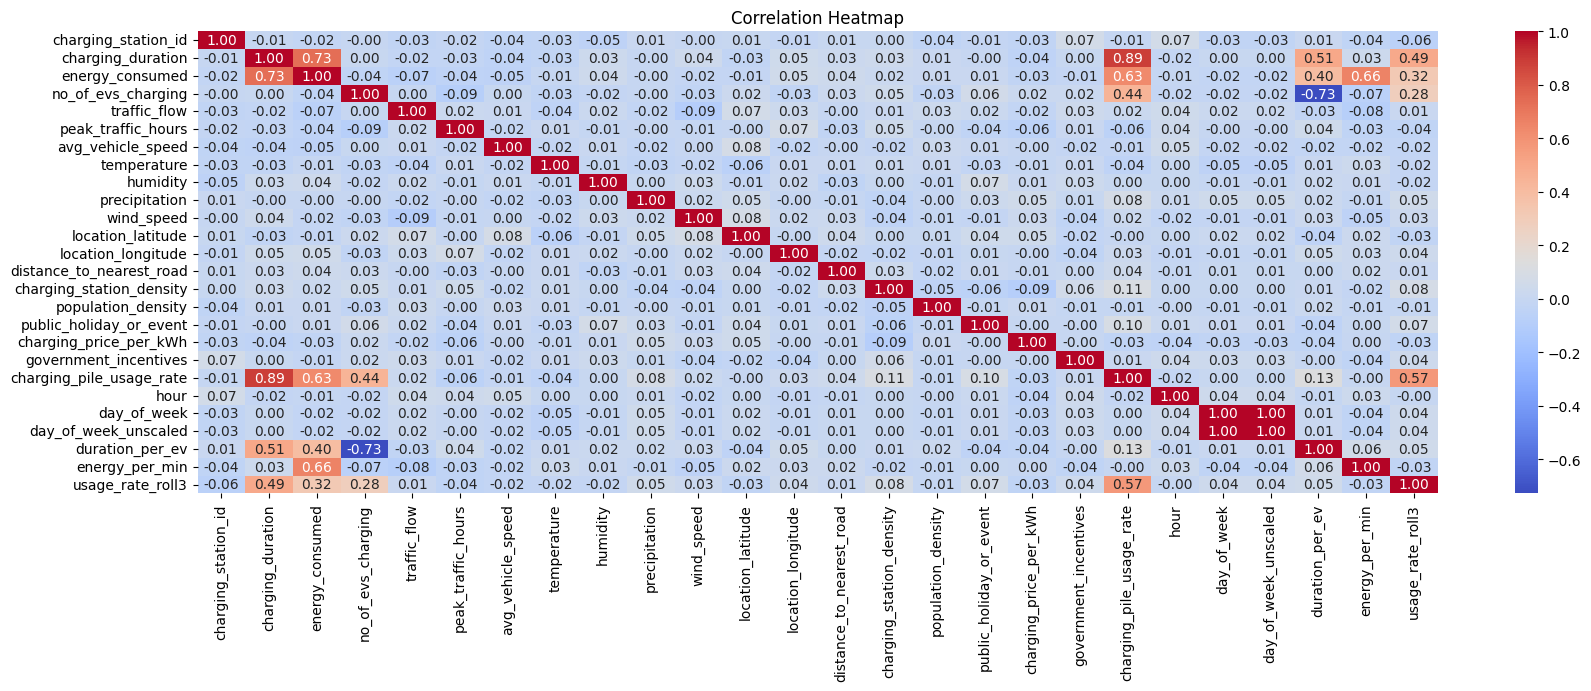

In [22]:
plt.figure(figsize=(20, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

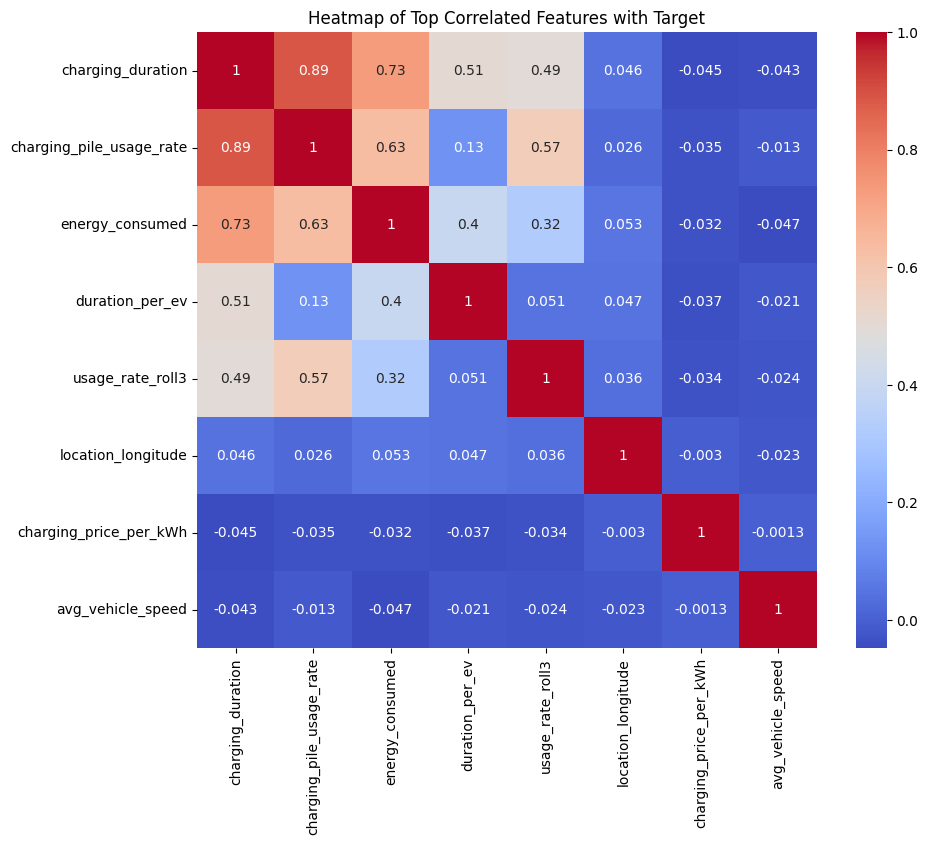

In [23]:
# Select top 8 correlated features including the target itself
top_corr_features = correlation_matrix['charging_duration'].abs().sort_values(ascending=False).head(8).index
# to make it visually readable
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap of Top Correlated Features with Target")
plt.show()

### 1.3.2 & 1.3.3 - Compare Features and Relationships between Features

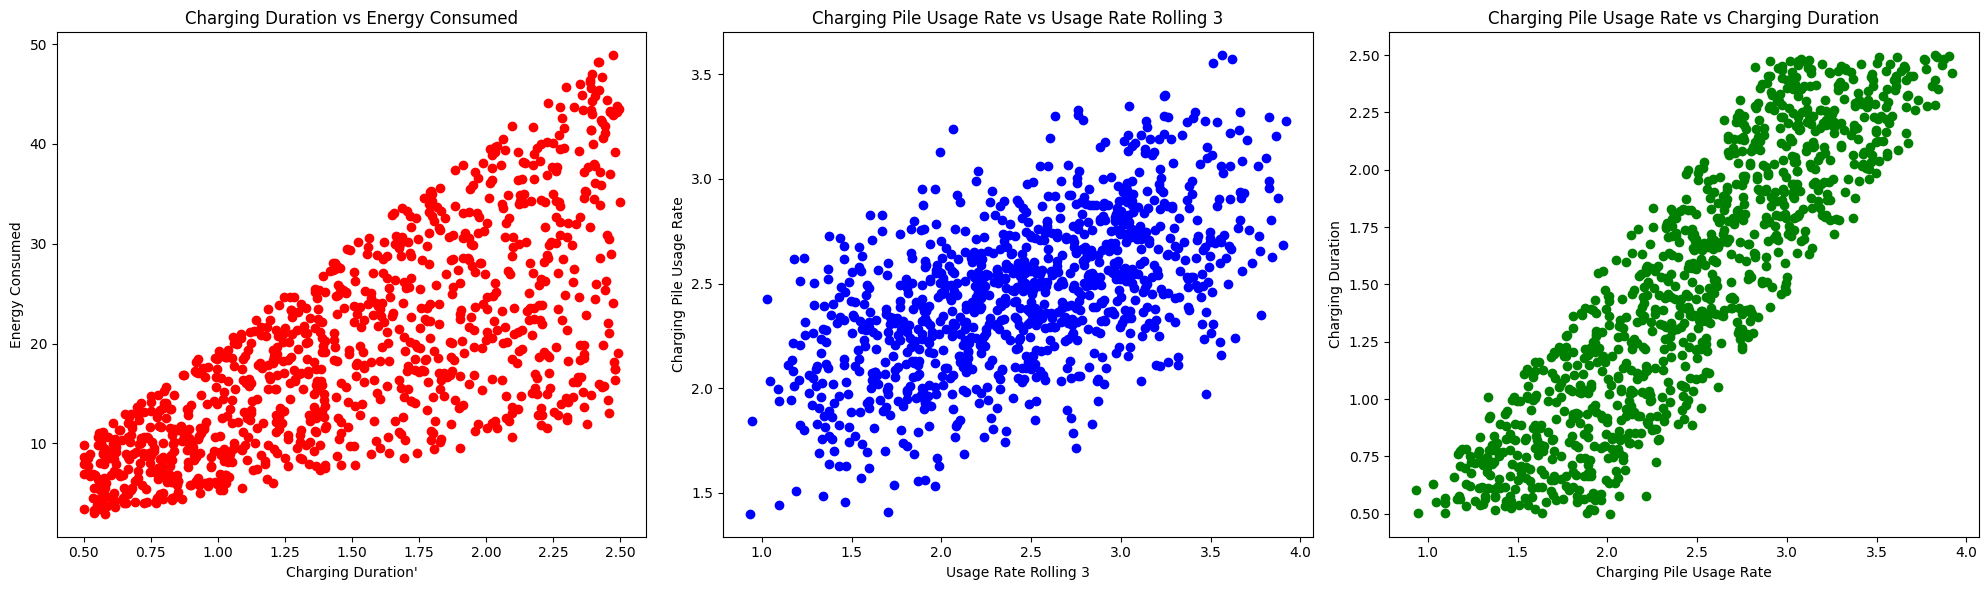

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(x=df['charging_duration'], y=df['energy_consumed'], color='red')
axes[0].set_title("Charging Duration vs Energy Consumed")
axes[0].set_ylabel("Energy Consumed")
axes[0].set_xlabel("Charging Duration'")

axes[1].scatter(x=df['charging_pile_usage_rate'], y=df['usage_rate_roll3'], color='blue')
axes[1].set_title("Charging Pile Usage Rate vs Usage Rate Rolling 3")
axes[1].set_ylabel("Charging Pile Usage Rate")
axes[1].set_xlabel("Usage Rate Rolling 3")

axes[2].scatter(x=df['charging_pile_usage_rate'], y=df['charging_duration'], color='green')
axes[2].set_title("Charging Pile Usage Rate vs Charging Duration")
axes[2].set_ylabel("Charging Duration")
axes[2].set_xlabel("Charging Pile Usage Rate")

plt.tight_layout()
plt.show()

### 1.3.3 - Time-Series Trends

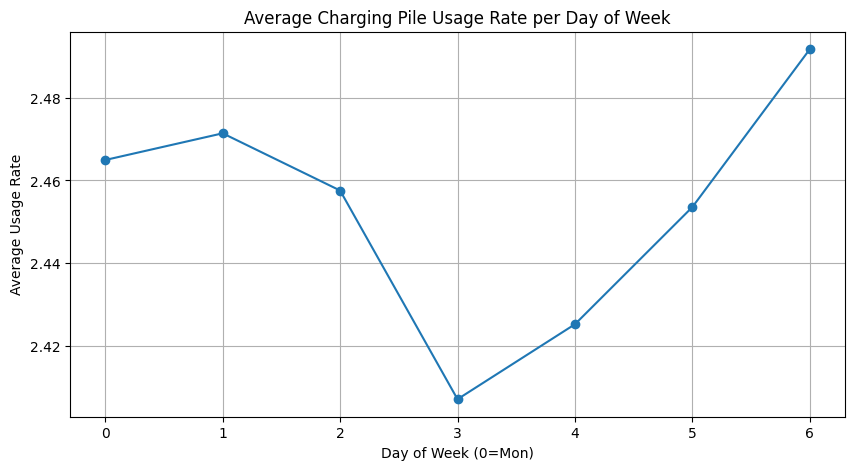

In [25]:
dow_trend = df.groupby('day_of_week_unscaled')['charging_pile_usage_rate'].mean()

plt.figure(figsize=(10,5))
plt.plot(dow_trend.index, dow_trend.values, marker='o')
plt.title("Average Charging Pile Usage Rate per Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Usage Rate")
plt.grid()
plt.show()

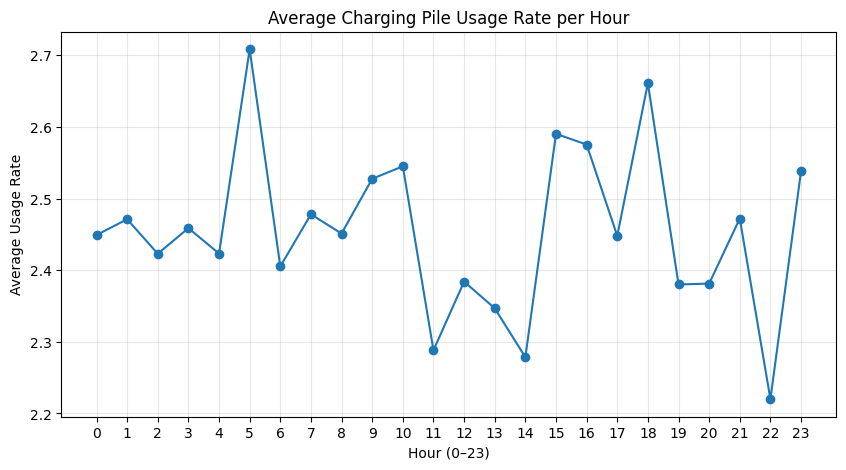

In [52]:
hour_trend = df.groupby('hour')['charging_pile_usage_rate'].mean()

plt.figure(figsize=(10,5))
plt.plot(hour_trend.index, hour_trend.values, marker='o')

plt.title("Average Charging Pile Usage Rate per Hour")
plt.xlabel("Hour (0–23)")
plt.ylabel("Average Usage Rate")

plt.xticks(range(0, 24))  # show all hours clearly
plt.grid(alpha=0.3)
plt.show()

# 2. Prediction Tasks (ML Models)

## 2.1 - Regression Tasks

### 2.1.1 - RandomForestRegressor Model

In [26]:
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [27]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor ===")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

=== Random Forest Regressor ===
MAE  : 0.0750
RMSE : 0.0917
R²   : 0.9843


### 2.1.2 - Linear Regression Model

In [28]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [29]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("\n=== Linear Regression ===")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")


=== Linear Regression ===
MAE  : 0.0000
RMSE : 0.0000
R²   : 1.0000


### 2.1.3 - Decision Tree Regressor (DTR) Model

In [30]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

In [31]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("\n=== Decision Tree Regressor ===")
print(f"MAE  : {dt_mae:.4f}")
print(f"RMSE : {dt_rmse:.4f}")
print(f"R²   : {dt_r2:.4f}")


=== Decision Tree Regressor ===
MAE  : 0.1087
RMSE : 0.1412
R²   : 0.9628


### 2.1.4 - XGBoost Model

In [32]:
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,subsample=0.9, colsample_bytree=0.9, random_state=42,objective="reg:squarederror")

xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

In [33]:

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("\n=== XGBoost Regressor ===")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")


=== XGBoost Regressor ===
MAE  : 0.0625
RMSE : 0.0818
R²   : 0.9875


### 2.1.5 - Graphing Results

In [34]:
results_df = pd.DataFrame([
    ["Random Forest", rf_mae, rf_rmse, rf_r2],
    ["Linear Regression", lr_mae, lr_rmse, lr_r2],
    ["Decision Tree", dt_mae, dt_rmse, dt_r2],
    ["XGBoost", xgb_mae, xgb_rmse, xgb_r2]
], columns=["Model", "MAE", "RMSE", "R²"])

print("\n=== Regression Model Comparison ===")
print(results_df)


=== Regression Model Comparison ===
               Model           MAE          RMSE        R²
0      Random Forest  7.503509e-02  9.165950e-02  0.984317
1  Linear Regression  6.084022e-16  7.755685e-16  1.000000
2      Decision Tree  1.087248e-01  1.412422e-01  0.962761
3            XGBoost  6.254826e-02  8.183386e-02  0.987499


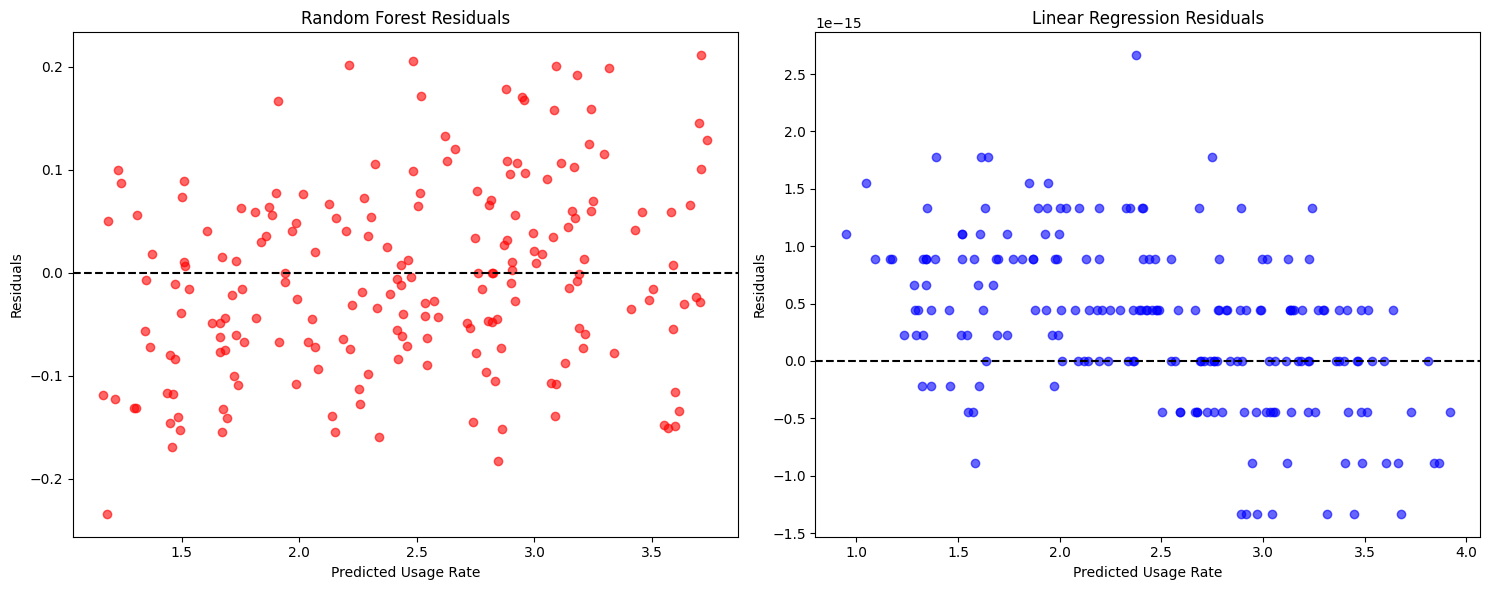

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1 — Random Forest
axes[0].scatter(y_pred_rf, y_test - y_pred_rf, color='red', alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title("Random Forest Residuals")
axes[0].set_xlabel("Predicted Usage Rate")
axes[0].set_ylabel("Residuals")

# 2 — Linear Regression
axes[1].scatter(y_pred_lr, y_test - y_pred_lr, color='blue', alpha=0.6)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("Linear Regression Residuals")
axes[1].set_xlabel("Predicted Usage Rate")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()


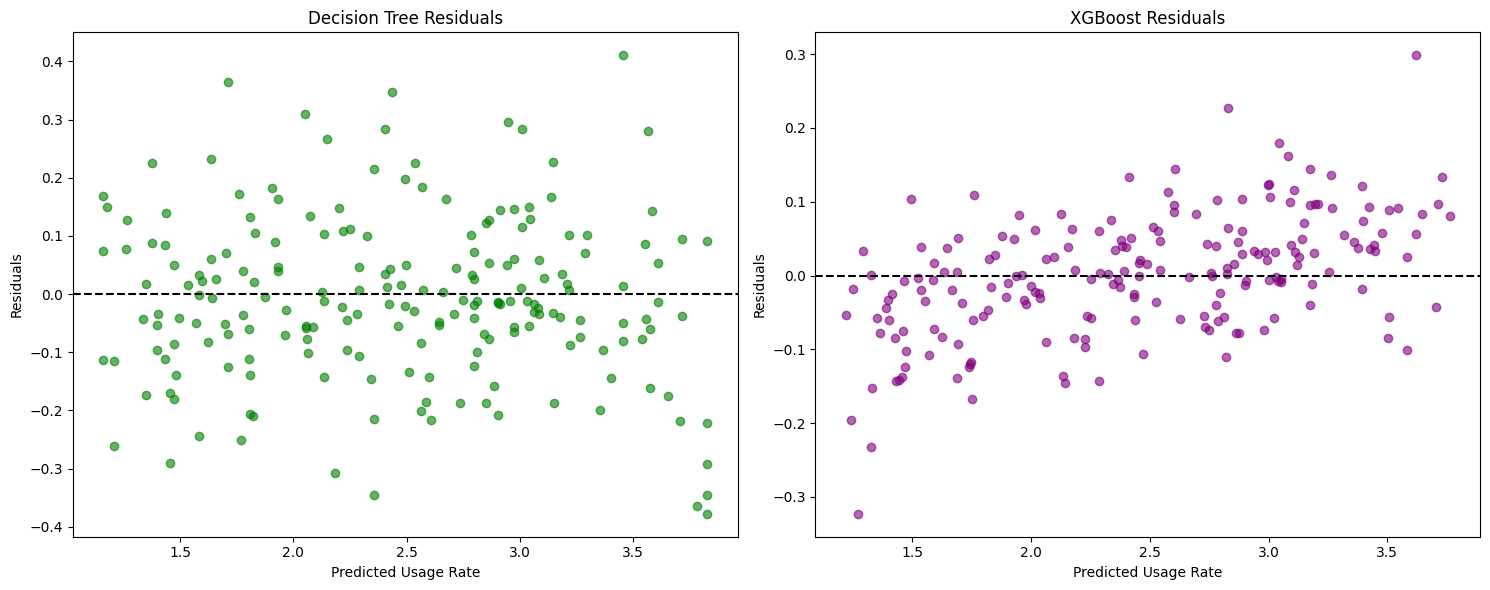

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# 3 — Decision Tree
axes[0].scatter(y_pred_dt, y_test - y_pred_dt, color='green', alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title("Decision Tree Residuals")
axes[0].set_xlabel("Predicted Usage Rate")
axes[0].set_ylabel("Residuals")

# 4 — XGBoost
axes[1].scatter(y_pred_xgb, y_test - y_pred_xgb, color='purple', alpha=0.6)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("XGBoost Residuals")
axes[1].set_xlabel("Predicted Usage Rate")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [37]:
models = ["Random Forest", "Linear Regression", "Decision Tree","XGBoost"]

r2_values = [rf_r2, lr_r2, dt_r2, xgb_r2]
mae_values = [rf_mae, lr_mae, dt_mae, xgb_mae]
rmse_values = [rf_rmse, lr_rmse, dt_rmse, xgb_rmse]

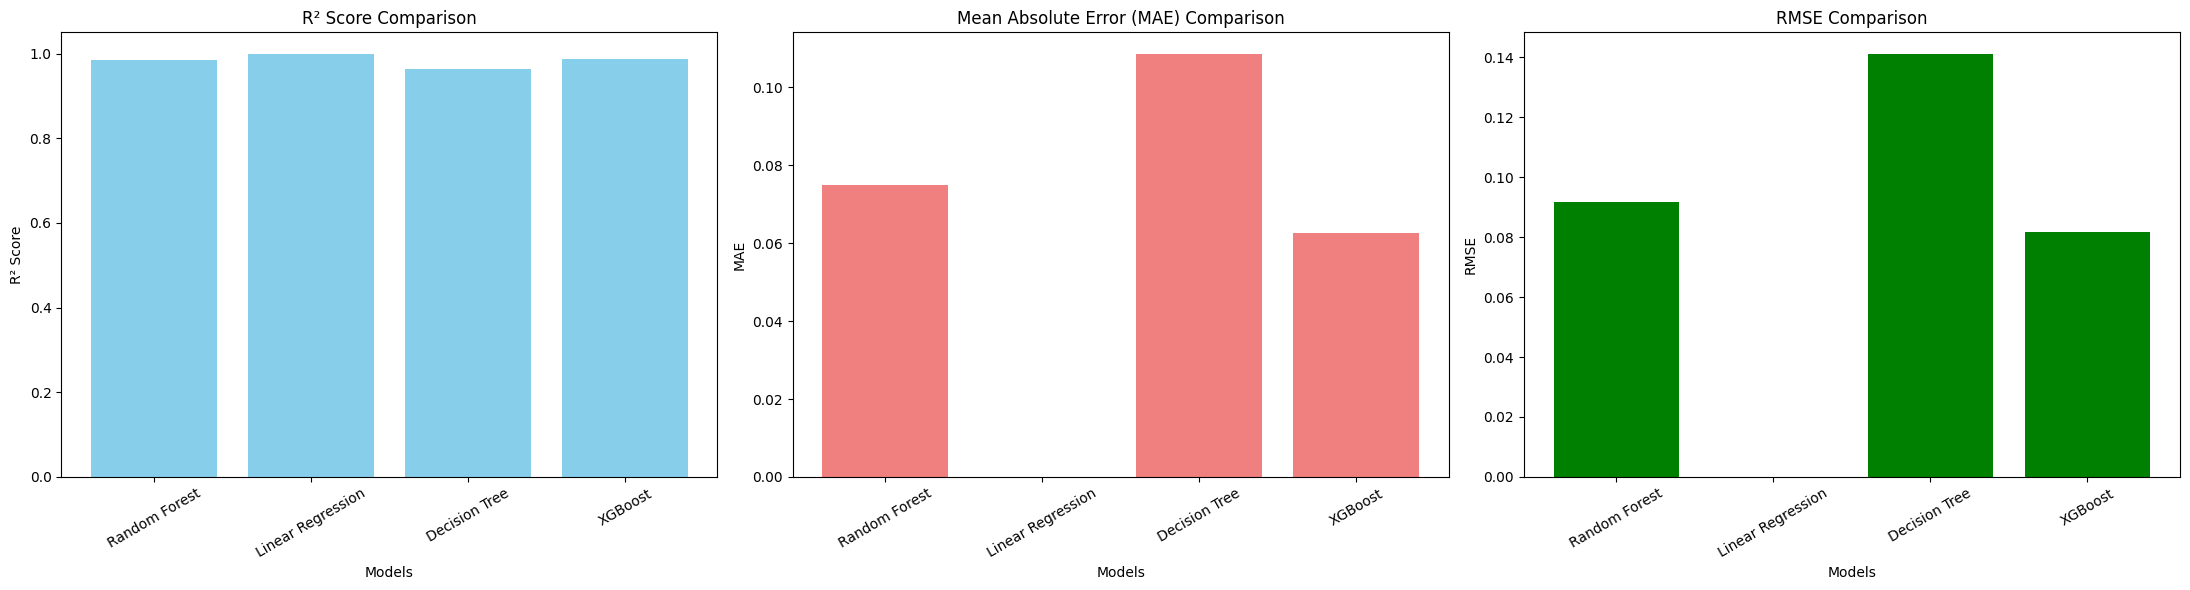

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# === R² Comparison ===
axes[0].bar(models, r2_values, color='skyblue')
axes[0].set_title("R² Score Comparison")
axes[0].set_ylabel("R² Score")
axes[0].set_xlabel("Models")
axes[0].tick_params(axis='x', rotation=30)

# === MAE Comparison ===
axes[1].bar(models, mae_values, color='lightcoral')
axes[1].set_title("Mean Absolute Error (MAE) Comparison")
axes[1].set_ylabel("MAE")
axes[1].set_xlabel("Models")
axes[1].tick_params(axis='x', rotation=30)

# === RMSE Comparison ===
axes[2].bar(models, rmse_values, color='green')
axes[2].set_title("RMSE Comparison")
axes[2].set_ylabel("RMSE")
axes[2].set_xlabel("Models")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()